# 5D 시장 구조 분석

## tl;dr

- 분석 모집단은 정상 완료이면서 7개 공식 승식 매출이 모두 존재하는 4,582경주다.
- 31개월의 월별 경주당 평균 매출은 25.27억~32.12억원이고 변동계수는 약 5%다. 월은 제외 조건이 아니라 추세 확인 차원으로 유지한다.
- 서울은 2,698경주, 부산경남은 1,884경주다. 서울의 경주당 평균 매출은 30.34억원으로 부산경남 26.08억원보다 16% 높지만, 승식별 매출 비중 차이는 최대 0.93%p라 두 지역을 모두 사용한다.
- 등급별 경주당 평균 매출은 국6등급 21.95억원부터 1등급 40.08억원까지 차이가 있으므로 10개 등급을 모두 보존하고 비교 차원으로 통제한다.
- 삼복승식과 복승식은 전체 매출의 각각 34.2%, 31.5%를 차지한다. 다만 매출만으로 모델 대상 승식을 정할 수 없어 7개 승식을 유지하고 다음 단계에서 공식 적중배당 구조를 비교한다.


## Context & Methods

이 Notebook은 사업 수익성이 아니라 KRA API179 매출 데이터에서 관찰되는 시장 규모와 구성을 분석한다. 모델 성능, 적중률, ROI를 평가하지 않는다.

### Key Assumptions

- 원천은 `analytics.mart_market_sales`이며 Canonical과 대사를 통과한 `star_v1` 결과다.
- 한 행의 Grain은 경주 1건 × 승식 1개다.
- 모든 금액은 원 단위이며 월별 비교는 경주 수와 경주당 매출을 함께 본다.
- 매출은 시장 참여 규모의 보조지표이며 수익성 또는 모델 적용 가능성의 직접 증거가 아니다.
- 데이터 기준일은 Notebook 실행 시 DB에서 다시 읽는다.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
DB_PATH = PROJECT_ROOT / "data" / "warehouse" / "kra.duckdb"
SQL_DIR = PROJECT_ROOT / "sql" / "analysis"

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.options.display.float_format = "{:,.2f}".format

def query_file(connection: duckdb.DuckDBPyConnection, filename: str) -> pd.DataFrame:
    sql = (SQL_DIR / filename).read_text(encoding="utf-8")
    return connection.execute(sql).df()

connection = duckdb.connect(str(DB_PATH), read_only=True)


## Data

### 1. 분석 모집단 확인

Star Schema의 시장 적격 조건과 행 수를 먼저 확인한다.


In [2]:
scope = query_file(connection, "001_market_scope.sql")
scope


,date_min,date_max,race_count,race_pool_rows,pool_count,total_sales
0,2024-01-05,2026-07-26,4582,32074,7,"13,098,987,380,400.00"


In [3]:
assert int(scope.loc[0, "race_count"]) == 4582
assert int(scope.loc[0, "race_pool_rows"]) == 4582 * 7
assert int(scope.loc[0, "pool_count"]) == 7

monthly = query_file(connection, "002_monthly_market.sql")
meet = query_file(connection, "003_meet_market.sql")
grade = query_file(connection, "004_grade_market.sql")
pool = query_file(connection, "005_pool_market.sql")
pool_meet = query_file(connection, "006_pool_meet_market.sql")

assert int(monthly["race_count"].sum()) == 4582
assert int(meet["race_count"].sum()) == 4582
assert int(grade["race_count"].sum()) == 4582
assert pool["race_count"].eq(4582).all()
assert int(pool["total_sales"].sum()) == int(scope.loc[0, "total_sales"])


## Results

### 2. 월별 규모와 경주당 매출

월별 총매출은 경주 수의 영향을 크게 받으므로 경주 수와 경주당 매출을 분리해서 본다.


In [4]:
monthly_view = monthly.assign(
    total_sales_100m=monthly["total_sales"] / 100_000_000,
    average_sales_per_race_100m=monthly["average_sales_per_race"] / 100_000_000,
    median_sales_per_race_100m=monthly["median_sales_per_race"] / 100_000_000,
)

monthly_summary = pd.Series({
    "months": len(monthly_view),
    "race_count_min": monthly_view["race_count"].min(),
    "race_count_max": monthly_view["race_count"].max(),
    "avg_sales_per_race_min_100m": monthly_view["average_sales_per_race_100m"].min(),
    "avg_sales_per_race_max_100m": monthly_view["average_sales_per_race_100m"].max(),
    "monthly_avg_sales_cv": (
        monthly_view["average_sales_per_race"].std(ddof=1)
        / monthly_view["average_sales_per_race"].mean()
    ),
})
display(monthly_summary.to_frame("value"))
display(monthly_view[[
    "year_month", "race_count", "total_sales_100m",
    "average_sales_per_race_100m", "median_sales_per_race_100m"
]])


,value
months,31.00
race_count_min,108.00
race_count_max,180.00
avg_sales_per_race_min_100m,25.27
avg_sales_per_race_max_100m,32.12
monthly_avg_sales_cv,0.05


,year_month,race_count,total_sales_100m,average_sales_per_race_100m,median_sales_per_race_100m
0,2024-01,144,"4,152.72",28.84,30.59
1,2024-02,108,"3,133.03",29.01,30.04
2,2024-03,180,"5,208.07",28.93,29.29
3,2024-04,144,"3,991.69",27.72,28.13
4,2024-05,152,"4,146.39",27.28,27.67
5,2024-06,172,"5,273.11",30.66,31.38
6,2024-07,127,"4,079.85",32.12,33.31
7,2024-08,155,"4,741.39",30.59,31.03
8,2024-09,123,"3,949.63",32.11,31.73
9,2024-10,144,"4,043.59",28.08,28.39


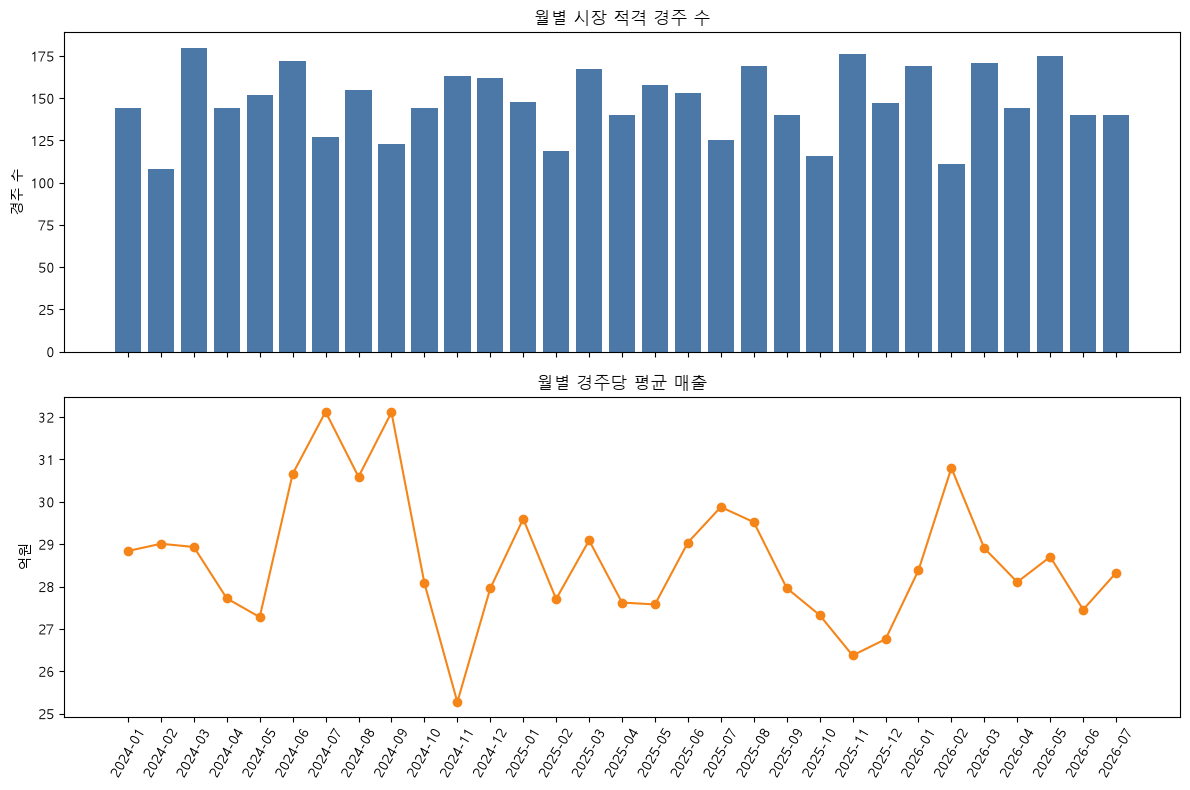

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].bar(monthly_view["year_month"], monthly_view["race_count"], color="#4C78A8")
axes[0].set_title("월별 시장 적격 경주 수")
axes[0].set_ylabel("경주 수")

axes[1].plot(
    monthly_view["year_month"],
    monthly_view["average_sales_per_race_100m"],
    marker="o",
    color="#F58518",
)
axes[1].set_title("월별 경주당 평균 매출")
axes[1].set_ylabel("억원")
axes[1].tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()


### 3. 서울과 부산경남 비교

총매출뿐 아니라 경주 수 비중, 매출 비중, 경주당 평균·중앙값을 함께 비교한다.


In [6]:
meet_view = meet.assign(
    race_share=meet["race_count"] / meet["race_count"].sum(),
    sales_share=meet["total_sales"] / meet["total_sales"].sum(),
    total_sales_100m=meet["total_sales"] / 100_000_000,
    average_sales_per_race_100m=meet["average_sales_per_race"] / 100_000_000,
    median_sales_per_race_100m=meet["median_sales_per_race"] / 100_000_000,
)
meet_view[[
    "meet_name", "race_count", "race_share", "total_sales_100m", "sales_share",
    "average_sales_per_race_100m", "median_sales_per_race_100m"
]]


,meet_name,race_count,race_share,total_sales_100m,sales_share,average_sales_per_race_100m,median_sales_per_race_100m
0,서울,2698,0.59,"81,859.42",0.62,30.34,30.38
1,부산경남,1884,0.41,"49,130.45",0.38,26.08,24.11


In [7]:
seoul = meet_view.loc[meet_view["meet_code"] == 1].iloc[0]
busan = meet_view.loc[meet_view["meet_code"] == 3].iloc[0]
meet_comparison = pd.Series({
    "seoul_minus_busan_race_share_pp": (seoul["race_share"] - busan["race_share"]) * 100,
    "seoul_minus_busan_sales_share_pp": (seoul["sales_share"] - busan["sales_share"]) * 100,
    "seoul_avg_sales_premium": (
        seoul["average_sales_per_race"] / busan["average_sales_per_race"] - 1
    ),
    "seoul_median_sales_premium": (
        seoul["median_sales_per_race"] / busan["median_sales_per_race"] - 1
    ),
})
meet_comparison.to_frame("value")


,value
seoul_minus_busan_race_share_pp,17.77
seoul_minus_busan_sales_share_pp,24.99
seoul_avg_sales_premium,0.16
seoul_median_sales_premium,0.26


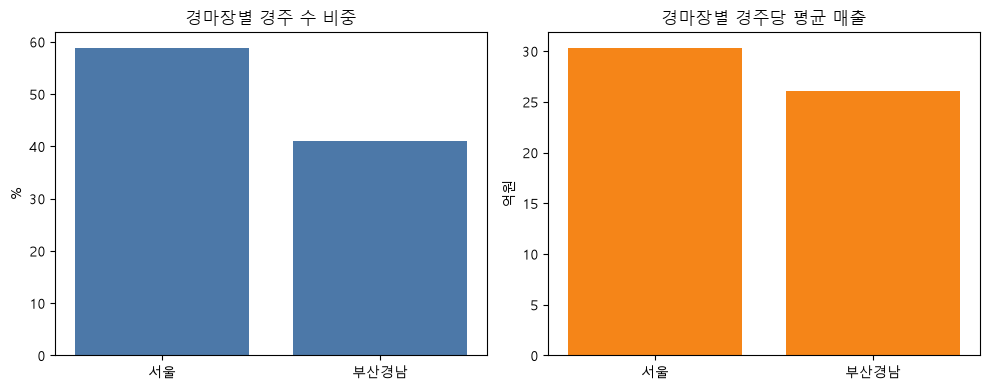

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(meet_view["meet_name"], meet_view["race_share"] * 100, color="#4C78A8")
axes[0].set_title("경마장별 경주 수 비중")
axes[0].set_ylabel("%")
axes[1].bar(
    meet_view["meet_name"], meet_view["average_sales_per_race_100m"], color="#F58518"
)
axes[1].set_title("경마장별 경주당 평균 매출")
axes[1].set_ylabel("억원")
fig.tight_layout()
plt.show()


### 4. 등급별 규모

등급은 선택·제외하지 않고 경주 수와 경주당 매출의 차이를 설명하는 분석 차원으로 유지한다.


In [9]:
grade_view = grade.assign(
    race_share=grade["race_count"] / grade["race_count"].sum(),
    sales_share=grade["total_sales"] / grade["total_sales"].sum(),
    total_sales_100m=grade["total_sales"] / 100_000_000,
    average_sales_per_race_100m=grade["average_sales_per_race"] / 100_000_000,
    median_sales_per_race_100m=grade["median_sales_per_race"] / 100_000_000,
)
grade_view[[
    "race_grade_raw", "grade_scope", "race_count", "race_share",
    "total_sales_100m", "sales_share", "average_sales_per_race_100m",
    "median_sales_per_race_100m"
]]


,race_grade_raw,grade_scope,race_count,race_share,total_sales_100m,sales_share,average_sales_per_race_100m,median_sales_per_race_100m
0,1등급,REGULAR,123,0.03,"4,929.70",0.04,40.08,39.83
1,2등급,REGULAR,216,0.05,"7,174.91",0.05,33.22,33.47
2,국3등급,REGULAR,240,0.05,"7,928.18",0.06,33.03,34.13
3,혼3등급,REGULAR,308,0.07,"10,022.76",0.08,32.54,32.50
4,국4등급,REGULAR,520,0.11,"16,385.26",0.13,31.51,32.11
5,혼4등급,REGULAR,627,0.14,"19,215.16",0.15,30.65,31.17
6,국5등급,REGULAR,1178,0.26,"33,791.72",0.26,28.69,29.27
7,국6등급,REGULAR,1248,0.27,"27,390.96",0.21,21.95,21.60
8,국OPEN,OPEN,64,0.01,"2,136.49",0.02,33.38,34.00
9,혼OPEN,OPEN,58,0.01,"2,014.72",0.02,34.74,34.92


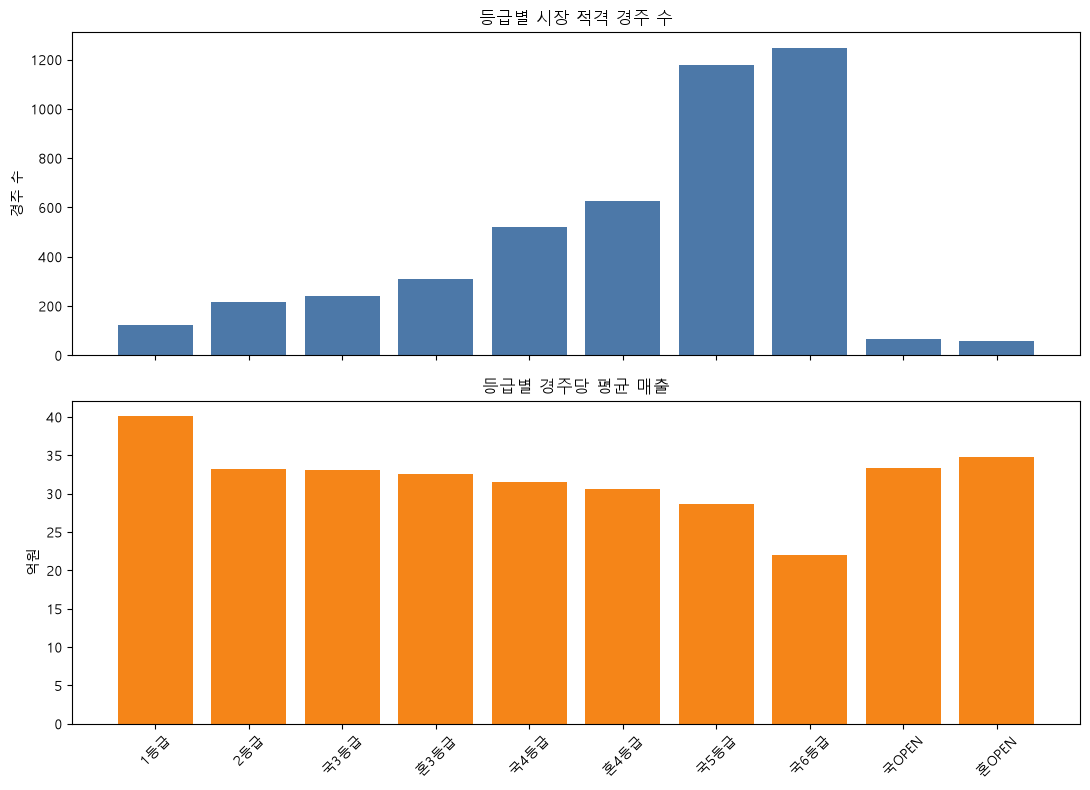

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].bar(grade_view["race_grade_raw"], grade_view["race_count"], color="#4C78A8")
axes[0].set_title("등급별 시장 적격 경주 수")
axes[0].set_ylabel("경주 수")
axes[1].bar(
    grade_view["race_grade_raw"], grade_view["average_sales_per_race_100m"], color="#F58518"
)
axes[1].set_title("등급별 경주당 평균 매출")
axes[1].set_ylabel("억원")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


### 5. 승식별 시장 구성

매출은 승식별 참여 규모를 보여주지만 모델 적합성이나 수익성을 직접 보여주지 않는다.


In [11]:
pool_view = pool.assign(
    market_share=pool["total_sales"] / pool["total_sales"].sum(),
    total_sales_100m=pool["total_sales"] / 100_000_000,
    average_sales_per_race_100m=pool["average_sales_per_race"] / 100_000_000,
    median_sales_per_race_100m=pool["median_sales_per_race"] / 100_000_000,
)
pool_view[[
    "pool_code", "pool_name_official", "selection_count", "order_matters",
    "total_sales_100m", "market_share", "average_sales_per_race_100m",
    "median_sales_per_race_100m"
]]


,pool_code,pool_name_official,selection_count,order_matters,total_sales_100m,market_share,average_sales_per_race_100m,median_sales_per_race_100m
0,WIN,단승식,1,False,"1,512.91",0.01,0.33,0.33
1,PLC,연승식,1,False,"2,269.07",0.02,0.50,0.50
2,QNL,복승식,2,False,"41,207.22",0.31,8.99,8.91
3,EXA,쌍승식,2,True,"12,586.39",0.10,2.75,2.73
4,QPL,복연승식,2,False,"5,489.08",0.04,1.20,1.22
5,TLA,삼복승식,3,False,"44,823.19",0.34,9.78,9.87
6,TRI,삼쌍승식,3,True,"23,102.02",0.18,5.04,5.06


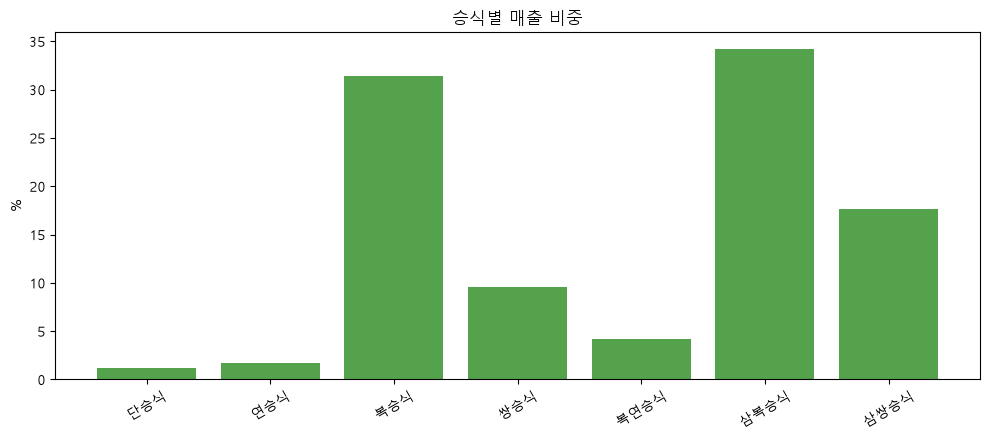

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(pool_view["pool_name_official"], pool_view["market_share"] * 100, color="#54A24B")
ax.set_title("승식별 매출 비중")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


### 6. 경마장별 승식 구성의 일관성

경마장에 따라 승식별 매출 비중이 크게 달라지는지 확인한다.


In [13]:
pool_meet_pivot = pool_meet.pivot(
    index=["pool_code", "pool_name_official"], columns="meet_name", values="market_share"
).reset_index()
pool_meet_pivot["absolute_gap_pp"] = (
    pool_meet_pivot["서울"] - pool_meet_pivot["부산경남"]
).abs() * 100
pool_meet_pivot.sort_values("absolute_gap_pp", ascending=False)


meet_name,pool_code,pool_name_official,부산경남,서울,absolute_gap_pp
2,QNL,복승식,0.31,0.32,0.93
5,TRI,삼쌍승식,0.18,0.17,0.66
4,TLA,삼복승식,0.34,0.34,0.33
0,EXA,쌍승식,0.10,0.10,0.13
3,QPL,복연승식,0.04,0.04,0.04
1,PLC,연승식,0.02,0.02,0.02
6,WIN,단승식,0.01,0.01,0.00


## Takeaways

1. **기간**: 월별 경주 수는 108~180경주지만 경주당 평균 매출의 월간 변동계수는 약 5%다. 월은 제외 기준보다 추세·이상치 확인용 차원으로 유지한다.
2. **경마장**: 서울은 경주 수 비중 58.9%, 매출 비중 62.5%이고 경주당 평균 매출이 부산경남보다 16% 높다. 그러나 승식별 매출 비중 차이는 최대 0.93%p이고 두 지역 모두 표본이 충분하므로 모두 사용하되 경마장 차원을 통제한다.
3. **등급**: 국5·국6등급이 전체 경주의 약 52.9%를 차지하며, 등급별 경주당 평균 매출은 21.95억~40.08억원이다. 규모와 강도가 서로 다르므로 10개 등급을 모두 유지한다.
4. **승식**: 삼복승식 34.2%, 복승식 31.5%, 삼쌍승식 17.6% 순으로 매출이 집중된다. 이는 시장 크기만 의미하므로 최종 후보 선정에는 공식 적중배당, 조합 난도, 기준 전략의 안정성 검토가 추가로 필요하다.
5. **다음 결정**: 현 단계에서는 승식을 제외하지 않는다. 다음 단계에서 `confirmed_odds_raw`를 승식별 적중 조합 구조로 정규화한 후 후보를 좁힌다.


In [14]:
connection.close()
